# Statistics US28, US30 and US31

## Imports

In [1]:
import os
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATASET_DECLARATIONS = 'Regression_dataset1_declarations.csv'
DATASET_HOLDINGS = 'Regression_dataset2_holdings.csv'

## US28 - Remuneration vs Asset Correlation (by role)

For a given role, Pearson's *r* between the total declared remuneration
(gross salary + side income) and each asset type (real estate, vehicles,
stocks), computed on each agent's first and last declaration so the two can be
compared (Statistics ch. 6).

In [2]:
ROLE = 'MP'

df28 = pd.read_csv(DATASET_DECLARATIONS)
df28['declaration_date'] = pd.to_datetime(df28['declaration_date'])
df28['total_remuneration'] = (df28['gross_salary']
                              + df28['side_income_consulting']
                              + df28['side_income_board_memberships'])
df28['total_assets'] = (df28['assets_in_real_estate']
                        + df28['assets_in_vehicles']
                        + df28['assets_in_stocks'])
df28 = df28[df28['role'] == ROLE]

asset_columns = {
    'Real Estate': 'assets_in_real_estate',
    'Vehicles': 'assets_in_vehicles',
    'Stocks': 'assets_in_stocks',
}

def interpret_correlation(r):
    a = abs(r)
    if a >= 0.8:
        return 'strong'
    if a >= 0.5:
        return 'moderate'
    if a >= 0.1:
        return 'weak'
    return 'negligible'

df_first = df28.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='first')
df_last = df28.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')

rows = []
for label, col in asset_columns.items():
    fit_first = stats.linregress(df_first['total_remuneration'], df_first[col])
    fit_last = stats.linregress(df_last['total_remuneration'], df_last[col])
    rows.append({
        'asset': label,
        'r (first)': round(fit_first.rvalue, 4),
        'p (first)': round(fit_first.pvalue, 4),
        'r (last)': round(fit_last.rvalue, 4),
        'p (last)': round(fit_last.pvalue, 4),
        'interpretation (last)': interpret_correlation(fit_last.rvalue),
    })
table28 = pd.DataFrame(rows).set_index('asset')
print('role:', ROLE, '| agents (first):', len(df_first), '| agents (last):', len(df_last))
overall = stats.linregress(df_last['total_remuneration'], df_last['total_assets'])
print(f'overall (last) remuneration vs TOTAL assets: r={overall.rvalue:.4f}  p={overall.pvalue:.4f}')
table28

role: MP | agents (first): 212 | agents (last): 212
overall (last) remuneration vs TOTAL assets: r=0.8134  p=0.0000


,r (first),p (first),r (last),p (last),interpretation (last)
asset,,,,,
Real Estate,0.0672,0.3300,0.0369,0.5934,negligible
Vehicles,-0.0137,0.8433,0.0411,0.5515,negligible
Stocks,-0.0383,0.5791,0.8571,0.0000,strong


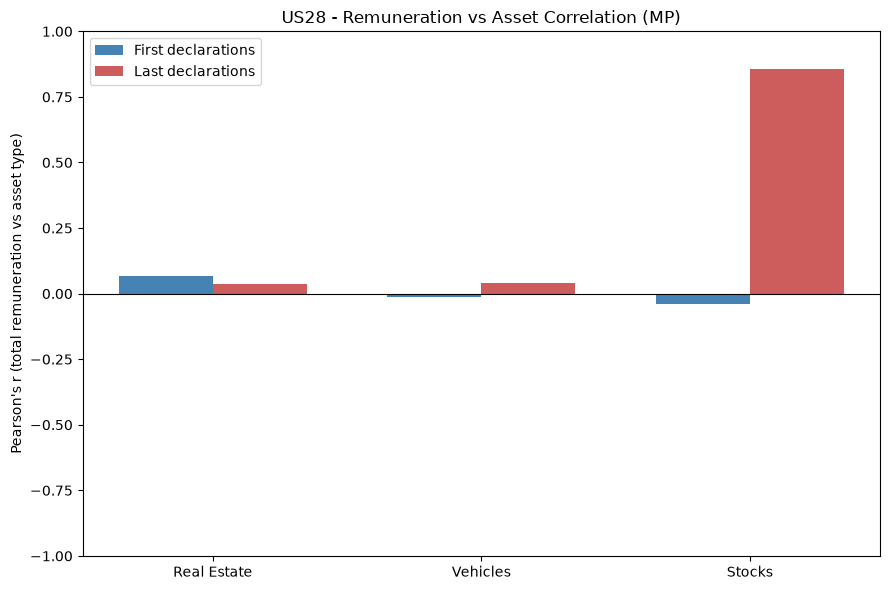

In [3]:
labels = list(asset_columns.keys())
first_values = [table28.loc[l, 'r (first)'] for l in labels]
last_values = [table28.loc[l, 'r (last)'] for l in labels]
pos = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar([p - width / 2 for p in pos], first_values, width, label='First declarations', color='steelblue')
ax.bar([p + width / 2 for p in pos], last_values, width, label='Last declarations', color='indianred')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(pos))
ax.set_xticklabels(labels)
ax.set_ylabel("Pearson's r (total remuneration vs asset type)")
ax.set_ylim(-1, 1)
ax.set_title(f'US28 - Remuneration vs Asset Correlation ({ROLE})')
ax.legend()
plt.tight_layout()
plt.show()

## US30 - Residual Analysis of the Income -> Assets Regression

Fits the linear regression total_assets ~ total_income on each agent's most
recent declaration, computes the residuals e_i = y_i - (slope*x_i + intercept)
and inspects their distribution against a Normal with the same mean and standard
deviation (Normality assumption of linear regression, ch. 6). This validates the
"agents with greatest deviation" of US29.

In [4]:
df30 = pd.read_csv(DATASET_DECLARATIONS)
df30['declaration_date'] = pd.to_datetime(df30['declaration_date'])
df30 = df30.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')
df30['total_income'] = (df30['gross_salary']
                        + df30['side_income_consulting']
                        + df30['side_income_board_memberships'])
df30['total_assets'] = (df30['assets_in_real_estate']
                        + df30['assets_in_vehicles']
                        + df30['assets_in_stocks'])

model = stats.linregress(df30['total_income'], df30['total_assets'])
res_original = df30['total_assets'] - (model.slope * df30['total_income'] + model.intercept)
res_normalized = (res_original - res_original.mean()) / res_original.std()

print(f'regression: assets = {model.slope:.4f} * income + {model.intercept:,.2f}')
print(f'r = {model.rvalue:.4f}    r^2 = {model.rvalue ** 2:.4f}')

n = len(res_original)
print('\nValidity check (observed vs Normal-expected beyond +/- k sigma):')
for k in (2.0, 3.0):
    obs = int((res_normalized.abs() > k).sum())
    exp = n * 2 * (1 - stats.norm.cdf(k))
    print(f'  |z| > {k:.0f}: observed = {obs:4d} ({obs / n:6.2%})   Normal-expected = {exp:6.1f} ({exp / n:6.2%})')

pd.DataFrame({'original': res_original.describe(), 'normalized (z-score)': res_normalized.describe()})

regression: assets = 3.8559 * income + 121,836.21
r = 0.8105    r^2 = 0.6569

Validity check (observed vs Normal-expected beyond +/- k sigma):
  |z| > 2: observed =   37 ( 4.47%)   Normal-expected =   37.7 ( 4.55%)
  |z| > 3: observed =    2 ( 0.24%)   Normal-expected =    2.2 ( 0.27%)


,original,normalized (z-score)
count,8.280000e+02,8.280000e+02
mean,-3.318118e-11,-4.290717e-18
std,1.160331e+05,1.000000e+00
min,-3.594362e+05,-3.097704e+00
25%,-8.257654e+04,-7.116635e-01
50%,-5.503709e+03,-4.743223e-02
75%,7.885298e+04,6.795731e-01
max,3.566482e+05,3.073676e+00


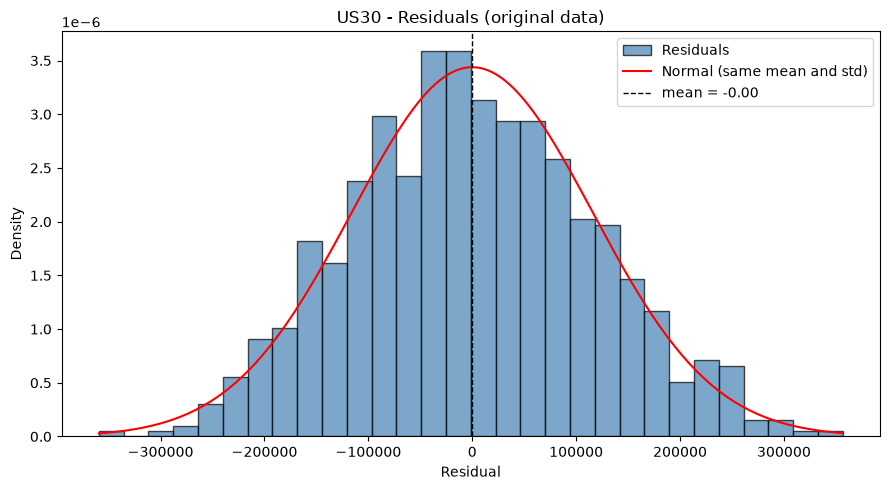

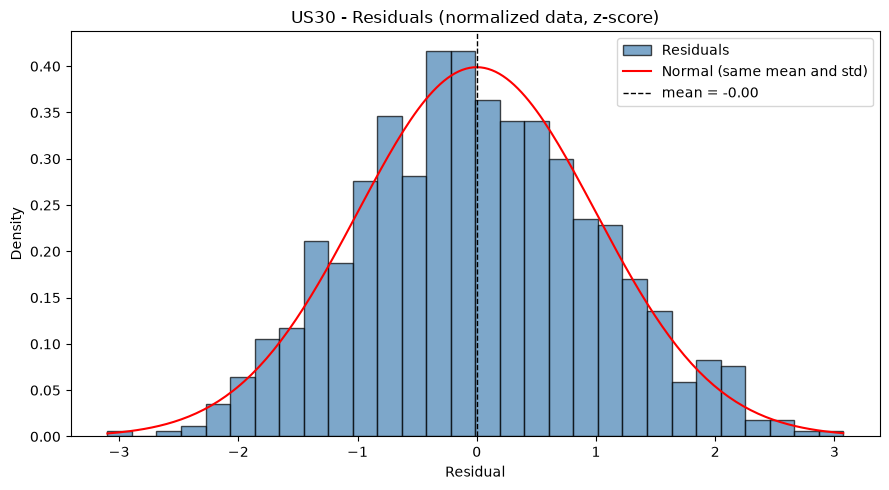

In [5]:
for residuals, title in [(res_original, 'US30 - Residuals (original data)'),
                         (res_normalized, 'US30 - Residuals (normalized data, z-score)')]:
    mean = residuals.mean()
    std = residuals.std()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(residuals, bins=30, density=True, color='steelblue', edgecolor='black', alpha=0.7, label='Residuals')
    if std > 0:
        xs = np.linspace(residuals.min(), residuals.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mean, std), 'r-', label='Normal (same mean and std)')
    ax.axvline(mean, color='black', linestyle='--', linewidth=1, label=f'mean = {mean:.2f}')
    ax.set_title(title)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

## US31 - Shareholding % vs Stock Value (linearity check)

Investigates whether the relationship between the shareholding percentage and
the total declared stock value is linear or accelerates at higher ownership
levels. Uses a least-squares linear fit + r^2 and a segmented (equal-width)
analysis by ownership level (ch. 6). Most recent declaration of each
agent/company pair only.

In [6]:
df31 = pd.read_csv(DATASET_HOLDINGS)
df31['declaration_date'] = pd.to_datetime(df31['declaration_date'])
df31 = df31.sort_values('declaration_date').drop_duplicates(subset=['agent_id', 'company_NIF'], keep='last')

model31 = stats.linregress(df31['company_percentage'], df31['total_value_in_stocks'])
print('LINEAR FIT (value ~ percentage)')
print(f'  line : value = {model31.slope:,.2f} * percentage + {model31.intercept:,.2f}')
print(f'  r    = {model31.rvalue:.4f}    r^2 = {model31.rvalue ** 2:.4f}')

df31['segment'] = pd.cut(df31['company_percentage'], bins=5)
rows = []
for segment, group in df31.groupby('segment', observed=True):
    if len(group) >= 2:
        seg_fit = stats.linregress(group['company_percentage'], group['total_value_in_stocks'])
        seg_slope = round(seg_fit.slope, 2)
    else:
        seg_slope = float('nan')
    rows.append({
        'range': f'[{segment.left:.2f}%, {segment.right:.2f}%]',
        'n': len(group),
        'mean_value': round(group['total_value_in_stocks'].mean(), 2),
        'slope': seg_slope,
    })
seg_table = pd.DataFrame(rows).set_index('range')
seg_table

LINEAR FIT (value ~ percentage)
  line : value = -1.13 * percentage + 102,936.64
  r    = -0.0001    r^2 = 0.0000


,n,mean_value,slope
range,,,
"[0.08%, 12.10%]",96,99467.97,-4648.41
"[12.10%, 24.07%]",106,106403.63,-8333.73
"[24.07%, 36.03%]",95,112356.14,117.12
"[36.03%, 48.00%]",106,77419.72,-3262.34
"[48.00%, 59.96%]",90,122481.21,7460.06


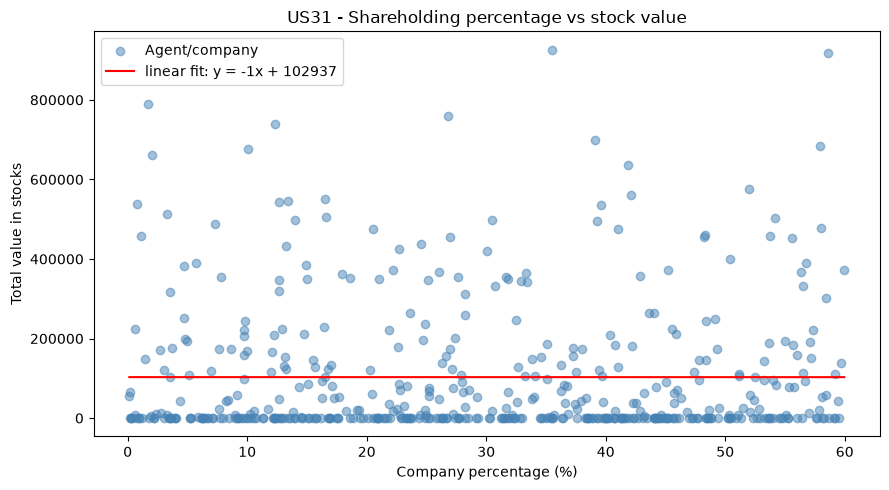

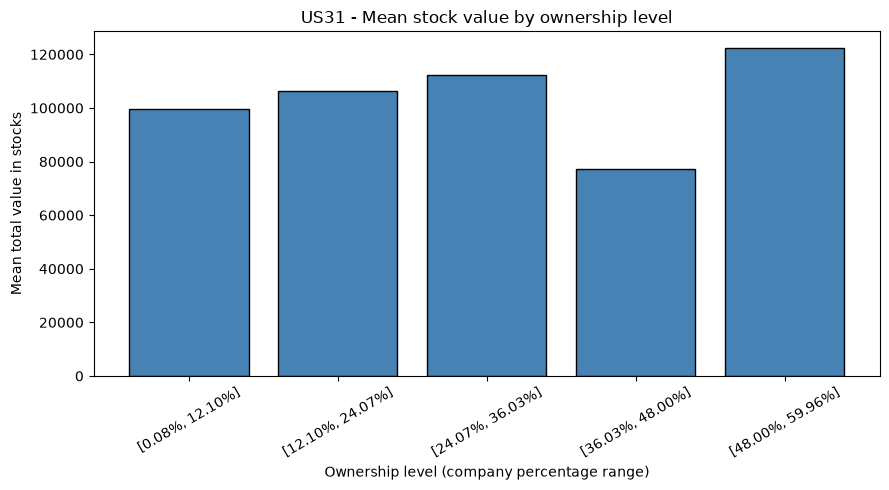

In [7]:
x = df31['company_percentage']
y = df31['total_value_in_stocks']

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color='steelblue', alpha=0.5, label='Agent/company')
lx = np.linspace(x.min(), x.max(), 100)
ax.plot(lx, model31.slope * lx + model31.intercept, color='red',
        label=f'linear fit: y = {model31.slope:.0f}x + {model31.intercept:.0f}')
ax.set_title('US31 - Shareholding percentage vs stock value')
ax.set_xlabel('Company percentage (%)')
ax.set_ylabel('Total value in stocks')
ax.legend()
plt.tight_layout()
plt.show()

labels31 = list(seg_table.index)
means31 = list(seg_table['mean_value'])
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels31, means31, color='steelblue', edgecolor='black')
ax.set_title('US31 - Mean stock value by ownership level')
ax.set_xlabel('Ownership level (company percentage range)')
ax.set_ylabel('Mean total value in stocks')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()